# 02 - Double Poisson

Línea base estadística. Modela el número de goles del local y del visitante como dos distribuciones de Poisson independientes condicionadas en las features del partido, y construye la distribución 1X2 sumando la matriz de marcadores resultante.

## 1. Setup

In [39]:
from pathlib import Path
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import poisson

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (log_loss)
import joblib
from tfm_segunda.evaluate_models import evaluar_modelo, graficar_matriz_confusion

PROJECT_ROOT = Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True, parents=True)
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

In [23]:
dataset_path = DATA_PROCESSED / "dataset_modelado.parquet"
df = pd.read_parquet(dataset_path)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nFilas por split:")
print(df['split'].value_counts())

Dataset cargado: 7,295 filas × 41 columnas

Filas por split:
split
train         4592
validation    1373
test           923
demo           407
Name: count, dtype: int64


In [24]:
train = df[df['split'] == 'train'].copy()
validation = df[df['split'] == 'validation'].copy()
test = df[df['split'] == 'test'].copy()

print(f"Train:      {len(train):>5,} filas  |  fechas {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Validation: {len(validation):>5,} filas  |  fechas {validation['date'].min().date()} → {validation['date'].max().date()}")
print(f"Test:       {len(test):>5,} filas  |  fechas {test['date'].min().date()} → {test['date'].max().date()}")

Train:      4,592 filas  |  fechas 2010-08-27 → 2020-08-07
Validation: 1,373 filas  |  fechas 2020-09-12 → 2023-05-28
Test:         923 filas  |  fechas 2023-08-11 → 2025-06-01


## 2. Decisiones sobre la construcción del modelo

Antes de implementar el modelo se documentan las cuatro decisiones que afectan a su construcción:

1. **Implementación con features como predictores.** En lugar de la formulación clásica con efectos fijos de equipo, se ajustan dos GLM Poisson separados (uno para los goles del local, otro para los del visitante) usando como predictores variables construidas en el notebook 01.

2. **Truncamiento de la matriz de marcadores a 8 goles por equipo.**

3. **Descarte de filas con NaN.** Los 178 partidos (2,4 % del dataset) con valores ausentes en alguna variable se descartan en el ajuste.

4. **Estandarización de features con `StandardScaler`.** Mejora la convergencia numérica del ajuste GLM, especialmente cuando las features tienen escalas muy distintas.

## 3. Preparación de features y target

Se separan los identificadores y las variables objetivo de las predictoras. El target principal del problema es la clase `ftr`, pero el Double Poisson modela los goles de cada equipo, por lo que también se separan `fthg` y `ftag`.

In [25]:
META_COLS = ['split', 'season', 'date', 'jornada', 'home_team', 'away_team']
TARGET_COLS = ['ftr', 'fthg', 'ftag']
FEATURE_COLS = [c for c in df.columns if c not in META_COLS + TARGET_COLS]

def preparar_xy(particion, feature_cols):
    mask_completas = particion[feature_cols].notna().all(axis=1)
    p = particion.loc[mask_completas].copy()
    
    X = p[feature_cols].astype(float)
    y_home = p['fthg'].astype(int)
    y_away = p['ftag'].astype(int)
    y_class = p['ftr']
    return X, y_home, y_away, y_class


X_train, y_train_home, y_train_away, y_train_class = preparar_xy(train, FEATURE_COLS)
X_val, y_val_home, y_val_away, y_val_class = preparar_xy(validation, FEATURE_COLS)
X_test, y_test_home, y_test_away, y_test_class = preparar_xy(test, FEATURE_COLS)

print(f"X_train: {X_train.shape}\nX_val: {X_val.shape}\nX_test: {X_test.shape}")

X_train: (4482, 32)
X_val: (1338, 32)
X_test: (901, 32)


In [26]:
scaler = StandardScaler()
X_train_s = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=FEATURE_COLS,
    index=X_train.index,
)
X_val_s = pd.DataFrame(
    scaler.transform(X_val),
    columns=FEATURE_COLS,
    index=X_val.index,
)
X_test_s = pd.DataFrame(
    scaler.transform(X_test),
    columns=FEATURE_COLS,
    index=X_test.index,
)

print(f"Media: {X_train_s.mean().mean():.6f}\nStd: {X_train_s.std().mean():.4f}")

Media: -0.000000
Std: 1.0001


## 4. Double Poisson

Se ajustan dos modelos lineales generalizados con función de enlace logarítmica:

$$\log(\lambda_{\text{home}}) = \beta_0 + \sum_{j=1}^{p} \beta_j x_j$$
$$\log(\lambda_{\text{away}}) = \gamma_0 + \sum_{j=1}^{p} \gamma_j x_j$$

donde $x_j$ son las features estandarizadas y los coeficientes se estiman por máxima verosimilitud.

### 4.1. Diagnóstico previo: número de condición de la matriz de diseño

Antes de ajustar los GLM se calcula el número de condición de la matriz de diseño estandarizada. Valores superiores a 30 indican multicolinealidad moderada y valores superiores a 100 sugieren multicolinealidad severa. La multicolinealidad no compromete la capacidad predictiva del modelo pero sí afecta a la estabilidad de los coeficientes individuales y a su interpretación.

In [27]:
X_train_const = sm.add_constant(X_train_s)
X_val_const = sm.add_constant(X_val_s)
X_test_const = sm.add_constant(X_test_s)

cond_number = np.linalg.cond(X_train_const.values)
print(f'Número de condición de la matriz de diseño: {cond_number:,.1f}')

if cond_number > 100:
    print('  → Multicolinealidad severa. Considerar regularización L2 como contingencia.')
elif cond_number > 30:
    print('  → Multicolinealidad moderada. Aceptable para predicción, vigilar interpretación de coeficientes.')
else:
    print('  → Sin multicolinealidad relevante.')

Número de condición de la matriz de diseño: 27.0
  → Sin multicolinealidad relevante.


### 4.2. Ajuste y métricas de bondad de ajuste

Se reportan tres métricas para cada GLM:

- Log-verosimilitud: utilizada como referencia y para el cálculo del Pseudo-$R^2$.
- Test de sobredispersión (Pearson $\chi^2$ / df residuales): valida la asunción central de la distribución de Poisson, $\mathbb{E}[Y \mid x] = \text{Var}[Y \mid x]$. Valores cercanos a 1 confirman la idoneidad de Poisson, mientras que valores claramente superiores a 1.5 indicarían sobredispersión.

In [28]:
def ajustar_glm_poisson(y, X_const, nombre):
    print(f'Ajustando GLM Poisson para {nombre}...')
    modelo = sm.GLM(y, X_const, family=sm.families.Poisson()).fit()
    
    dispersion = modelo.pearson_chi2 / modelo.df_resid
    
    print(f'  Convergencia:                 {modelo.converged}')
    print(f'  Log-likelihood:               {modelo.llf:.2f}')
    print(f'  Sobredispersión (Pearson/df): {dispersion:.4f}  ', end='')
    if dispersion < 1.1:
        print('→ asunción de Poisson razonable')
    elif dispersion < 1.5:
        print('→ leve sobredispersión, Poisson sigue siendo aceptable')
    else:
        print('→ sobredispersión relevante, valorar Binomial Negativa')
    return modelo

model_home = ajustar_glm_poisson(y_train_home, X_train_const, 'goles del local')
print()
model_away = ajustar_glm_poisson(y_train_away, X_train_const, 'goles del visitante')

Ajustando GLM Poisson para goles del local...
  Convergencia:                 True
  Log-likelihood:               -6578.20
  Sobredispersión (Pearson/df): 0.9339  → asunción de Poisson razonable

Ajustando GLM Poisson para goles del visitante...
  Convergencia:                 True
  Log-likelihood:               -5830.09
  Sobredispersión (Pearson/df): 1.0248  → asunción de Poisson razonable


## 5. Predicción de las tasas $\lambda$ y construcción de la matriz de marcadores

Con los dos GLM ajustados, para cualquier partido se obtienen las tasas esperadas de goles del local y del visitante como $\hat{\lambda}_{\text{home}} = \exp(\beta_0 + \beta^\top x)$ y $\hat{\lambda}_{\text{away}} = \exp(\gamma_0 + \gamma^\top x)$.

Asumiendo independencia condicional entre los goles de ambos equipos, la probabilidad de un marcador concreto $(i, j)$ se obtiene como el producto de dos distribuciones de Poisson independientes:

$$P(\text{Home}=i,\ \text{Away}=j \mid x) = \frac{\hat{\lambda}_{\text{home}}^{i} \, e^{-\hat{\lambda}_{\text{home}}}}{i!} \cdot \frac{\hat{\lambda}_{\text{away}}^{j} \, e^{-\hat{\lambda}_{\text{away}}}}{j!}$$

Truncando la matriz a $i, j \in \{0, 1, \dots, K\}$, la probabilidad de cada resultado 1X2 se obtiene sumando las regiones correspondientes.

$$P(H) = \sum_{i > j} P(i, j), \quad P(D) = \sum_{i = j} P(i, j), \quad P(A) = \sum_{i < j} P(i, j)$$

### 5.1. Verificación del truncamiento por defecto

El truncamiento $K = 8$ documentado en la decisión 2 se verifica sobre el conjunto de entrenamiento. El objetivo es confirmar que la masa de probabilidad excluida es despreciable.

In [29]:
MAX_GOALS = 8

n_train_total  = len(train)
n_excede_home  = (train['fthg'] > MAX_GOALS).sum()
n_excede_away  = (train['ftag'] > MAX_GOALS).sum()
n_excede_total = ((train['fthg'] > MAX_GOALS) | (train['ftag'] > MAX_GOALS)).sum()

print(f'Partidos de train totales:              {n_train_total:,}')
print(f'Partidos con goles_local      > {MAX_GOALS}:    {n_excede_home:>4}  ({n_excede_home/n_train_total:.4%})')
print(f'Partidos con goles_visitante  > {MAX_GOALS}:    {n_excede_away:>4}  ({n_excede_away/n_train_total:.4%})')
print(f'Partidos con algún equipo     > {MAX_GOALS}:    {n_excede_total:>4}  ({n_excede_total/n_train_total:.4%})')
print(f'\nMáximo histórico en train: local = {train["fthg"].max()}, visitante = {train["ftag"].max()}')

Partidos de train totales:              4,592
Partidos con goles_local      > 8:       0  (0.0000%)
Partidos con goles_visitante  > 8:       0  (0.0000%)
Partidos con algún equipo     > 8:       0  (0.0000%)

Máximo histórico en train: local = 7, visitante = 6


### 5.2. Funciones de inferencia

Se implementan tres funciones vectorizadas que toman como entrada las features estandarizadas con la constante añadida y devuelven, respectivamente, las tasas $\lambda$, la matriz de marcadores y las probabilidades 1X2.

In [30]:
def predecir_lambdas(X_const):
    lambda_home = model_home.predict(X_const).values
    lambda_away = model_away.predict(X_const).values
    return lambda_home, lambda_away


def construir_matriz_marcadores(lambda_home, lambda_away, max_goals=MAX_GOALS):
    goles  = np.arange(max_goals + 1)
    p_home = poisson.pmf(goles[None, :], lambda_home[:, None])
    p_away = poisson.pmf(goles[None, :], lambda_away[:, None])
    matriz = p_home[:, :, None] * p_away[:, None, :]
    return matriz


def probas_1x2_desde_matriz(matriz):
    n, g, _ = matriz.shape
    i_idx, j_idx = np.meshgrid(np.arange(g), np.arange(g), indexing='ij')
    mask_H = i_idx > j_idx
    mask_D = i_idx == j_idx
    mask_A = i_idx < j_idx
    
    p_H = (matriz * mask_H).sum(axis=(1, 2))
    p_D = (matriz * mask_D).sum(axis=(1, 2))
    p_A = (matriz * mask_A).sum(axis=(1, 2))
    
    total = p_H + p_D + p_A
    return pd.DataFrame({'A': p_A / total, 'D': p_D / total, 'H': p_H / total})

### 5.3. Generación de predicciones para los tres splits

In [31]:
lambda_train_h, lambda_train_a = predecir_lambdas(X_train_const)
lambda_val_h,   lambda_val_a   = predecir_lambdas(X_val_const)
lambda_test_h,  lambda_test_a  = predecir_lambdas(X_test_const)

matriz_train = construir_matriz_marcadores(lambda_train_h, lambda_train_a)
matriz_val   = construir_matriz_marcadores(lambda_val_h,   lambda_val_a)
matriz_test  = construir_matriz_marcadores(lambda_test_h,  lambda_test_a)

proba_train = probas_1x2_desde_matriz(matriz_train)
proba_val   = probas_1x2_desde_matriz(matriz_val)
proba_test  = probas_1x2_desde_matriz(matriz_test)

print(f'Lambdas train: home μ={lambda_train_h.mean():.3f} σ={lambda_train_h.std():.3f} | '
      f'away μ={lambda_train_a.mean():.3f} σ={lambda_train_a.std():.3f}')
print(f'Lambdas val:   home μ={lambda_val_h.mean():.3f} σ={lambda_val_h.std():.3f} | '
      f'away μ={lambda_val_a.mean():.3f} σ={lambda_val_a.std():.3f}')
print(f'Lambdas test:  home μ={lambda_test_h.mean():.3f} σ={lambda_test_h.std():.3f} | '
      f'away μ={lambda_test_a.mean():.3f} σ={lambda_test_a.std():.3f}')

Lambdas train: home μ=1.402 σ=0.245 | away μ=0.998 σ=0.171
Lambdas val:   home μ=1.401 σ=0.316 | away μ=1.094 σ=0.218
Lambdas test:  home μ=1.463 σ=0.294 | away μ=1.088 σ=0.197


### 5.4. Análisis de sensibilidad sobre `MAX_GOALS`

El umbral de truncamiento es el único hiperparámetro del modelo. Se evalúa el *log-loss* sobre el conjunto de validación para cuatro valores razonables del umbral. Dado que la masa de probabilidad descartada es del orden de $10^{-6}$ para $K = 8$, se espera que los cuatro resultados sean prácticamente idénticos. Documentar esta robustez evita que la elección del umbral pueda ser cuestionada como arbitraria.

In [32]:
LABELS = ['A', 'D', 'H']

encabezado = f"{'K':<4} {'log-loss val':<15} {'masa descartada máx':<22}"
print(encabezado)
print('-' * len(encabezado))
for k in [6, 8, 10, 12]:
    matriz_k = construir_matriz_marcadores(lambda_val_h, lambda_val_a, max_goals=k)
    proba_k  = probas_1x2_desde_matriz(matriz_k)
    ll       = log_loss(y_val_class, proba_k[LABELS].values, labels=LABELS)
    masa_max = np.abs(1 - matriz_k.sum(axis=(1, 2))).max()
    print(f'{k:<4} {ll:<15.6f} {masa_max:<22.2e}')

K    log-loss val    masa descartada máx   
-------------------------------------------
6    1.041269        2.35e-02              
8    1.041251        2.31e-03              
10   1.041249        1.53e-04              
12   1.041249        7.26e-06              


## 6. Evaluación bajo el marco común

Las métricas se calculan empleando la función que aplica el mismo protocolo a todos los modelos del trabajo para garantizar la comparabilidad. Las métricas reportadas son:

- **Accuracy y F1-Score macro**: rendimiento global y por clase respectivamente. La métrica macro promedia el F1 sin ponderar por frecuencia, lo que la hace especialmente sensible al rendimiento sobre la clase minoritaria (empate).
- **Log-loss multiclase**: penaliza la mala calibración de las probabilidades predichas. Se garantiza que las columnas del array de probabilidades estén en orden alfabético (`A`, `D`, `H`), que es el orden que *scikit-learn* asume internamente al recibir arrays multiclase. El argumento `labels=['A','D','H']` cumple aquí la función de fijar el orden de filas y columnas de la matriz de confusión y el orden del F1 por clase, no la de reordenar las probabilidades.
- **F1 por clase**: la literatura identifica el empate como la clase más difícil de predecir, por lo que se monitoriza de forma específica.

El valor de referencia obtenido en el notebook 00 (*log-loss* = 1.037 para las probabilidades implícitas del mercado de apuestas) actúa como *benchmark* mínimo a batir.

In [33]:
LOG_LOSS_MERCADO = 1.037

def evaluar_split(nombre, y_true, proba_df):
    y_pred_class = proba_df.idxmax(axis=1).values
    y_pred_proba = proba_df[LABELS].values
    return evaluar_modelo(
        y_true       = y_true,
        y_pred_class = y_pred_class,
        y_pred_proba = y_pred_proba,
        nombre_modelo = f'Double Poisson · {nombre}',
        verbose      = True,
    )

resultado_train = evaluar_split('Train',      y_train_class, proba_train)
resultado_val   = evaluar_split('Validation', y_val_class,   proba_val)
resultado_test  = evaluar_split('Test',       y_test_class,  proba_test)

df_resultados = pd.DataFrame([resultado_train, resultado_val, resultado_test])
df_resultados['split'] = ['train', 'validation', 'test']

=== Double Poisson · Train ===
  Accuracy     : 0.4775
  F1-macro     : 0.3031
  F1 por clase : A=0.2706  D=0.0000  H=0.6386
  Log-loss     : 1.0376

  Matriz de confusión (filas=verdadero, columnas=predicho, orden A/D/H):
        pred_A  pred_D  pred_H
true_A     222       0     885
true_D     171       0    1145
true_H     141       0    1918

=== Double Poisson · Validation ===
  Accuracy     : 0.4604
  F1-macro     : 0.3299
  F1 por clase : A=0.3750  D=0.0000  H=0.6148
  Log-loss     : 1.0413

  Matriz de confusión (filas=verdadero, columnas=predicho, orden A/D/H):
        pred_A  pred_D  pred_H
true_A     126       0     215
true_D     108       0     302
true_H      97       0     490

=== Double Poisson · Test ===
  Accuracy     : 0.4861
  F1-macro     : 0.3341
  F1 por clase : A=0.3613  D=0.0000  H=0.6410
  Log-loss     : 1.0339

  Matriz de confusión (filas=verdadero, columnas=predicho, orden A/D/H):
        pred_A  pred_D  pred_H
true_A      71       0     147
true_D      52 

### 6.1. Matrices de confusión

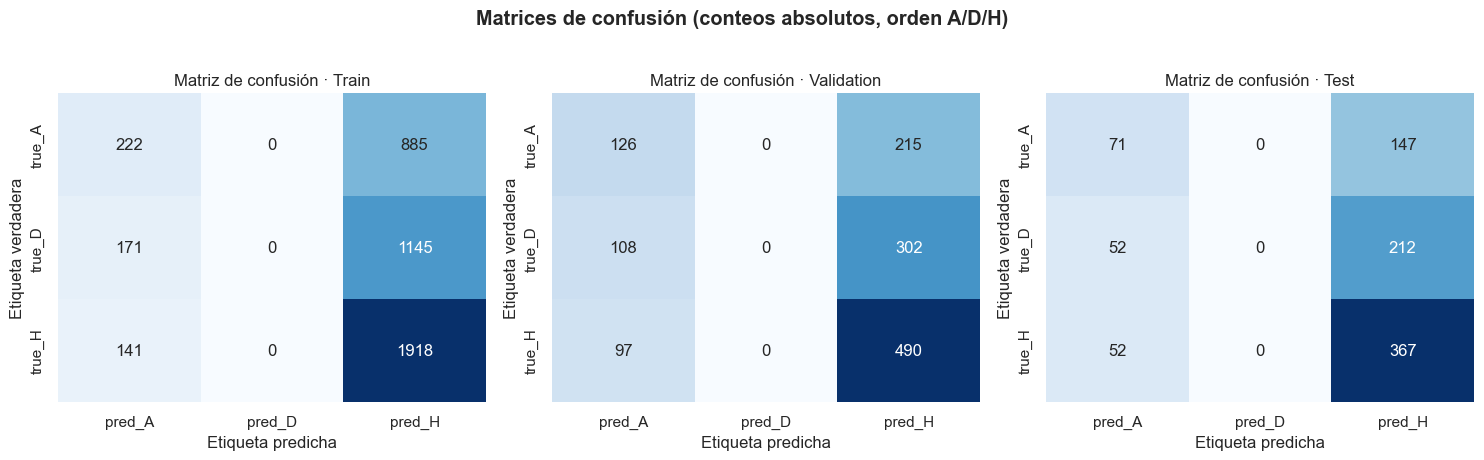

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (nombre, resultado) in zip(
    axes,
    [('Train', resultado_train),
     ('Validation', resultado_val),
     ('Test',  resultado_test)],
):
    cm = np.array(resultado['confusion_matrix'])
    graficar_matriz_confusion(cm, LABELS, nombre, ax=ax)

plt.suptitle('Matrices de confusión (conteos absolutos, orden A/D/H)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

Las matrices de confusión evidencian un patrón consistente, la columna `pred_D` aparece vacía. El modelo no asigna en ningún partido la etiqueta de empate como clase de máxima probabilidad. Este omportamiento, lejos de constituir un fallo del ajuste, responde a una propiedad estructural del *Double Poisson* comentada en el estado del arte. 

Esta limitación intrínseca justifica priorizar el F1-*macro* y el *log-loss* frente a la *accuracy* en la evaluación comparativa, dado que ambas métricas penalizan adecuadamente la incapacidad de discriminar la clase minoritaria, mientras que la *accuracy* podría premiar artificialmente a un clasificador que ignorase el empate por construcción.

## 7. Análisis del modelo

Se va a observar como afecta la zero-inflation y los resultados cortos, y además a cuantificar la ventaja de los locales

La asunción de independencia condicional entre los goles del local y del visitante ha sido cuestionada, ya que en los marcadores cortos existe una correlación negativa que el modelo independiente no captura.

Para contrastar empíricamente la presencia de este sesgo sobre el conjunto de prueba, se calcula para cada marcador la frecuencia observada y la frecuencia esperada según el modelo sobre los mismos partidos. Un ratio observado/esperado superior a 1 indica subestimación. 

Se incluyen además dos marcadores de control que la literatura no señala como problemáticos, para comprobar que el patrón es selectivo y no un sesgo global del ajuste.

In [35]:
marcadores_dc = [(0, 0), (1, 0), (0, 1), (1, 1)]
n_test = len(y_test_class)

filas = []
for i, j in marcadores_dc:
    p_obs = ((y_test_home.values == i) & (y_test_away.values == j)).sum() / n_test
    p_esp = matriz_test[:, i, j].mean()
    filas.append({
        'Marcador':         f'{i}-{j}',
        'Frec. observada':  p_obs,
        'Frec. esperada':   p_esp,
        'Ratio obs/esp':    p_obs / p_esp if p_esp > 0 else np.nan,
    })

for i, j in [(2, 1), (1, 2)]:
    p_obs = ((y_test_home.values == i) & (y_test_away.values == j)).sum() / n_test
    p_esp = matriz_test[:, i, j].mean()
    filas.append({
        'Marcador':         f'{i}-{j}',
        'Frec. observada':  p_obs,
        'Frec. esperada':   p_esp,
        'Ratio obs/esp':    p_obs / p_esp if p_esp > 0 else np.nan,
    })

tabla_dc = pd.DataFrame(filas)
print(tabla_dc.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Marcador  Frec. observada  Frec. esperada  Ratio obs/esp
     0-0           0.1043          0.0799         1.3061
     1-0           0.1365          0.1134         1.2041
     0-1           0.0788          0.0867         0.9088
     1-1           0.1210          0.1205         1.0039
     2-1           0.0921          0.0867         1.0629
     1-2           0.0488          0.0660         0.7404


Se observa que el problema solo se da en los marcadores 0-0 y 1-0.

### 7.4. Ventaja local

La constante de cada GLM proporciona una estimación de la tasa media de goles para un partido entre dos equipos hipotéticos de fuerza promedio. La diferencia representa, en consecuencia, la ventaja local media implícita del modelo, expresada en goles esperados.

In [36]:
lambda_home_neutro = np.exp(model_home.params['const'])
lambda_away_neutro = np.exp(model_away.params['const'])
ventaja_local_implicita = lambda_home_neutro - lambda_away_neutro

print(f'λ_home medio: {lambda_home_neutro:.4f} goles esperados')
print(f'λ_away medio: {lambda_away_neutro:.4f} goles esperados')
print(f'Ventaja local implícita: {ventaja_local_implicita:+.4f} goles a favor del local')

λ_home medio: 1.3817 goles esperados
λ_away medio: 0.9845 goles esperados
Ventaja local implícita: +0.3972 goles a favor del local


## 8. Resumen final y persistencia del modelo

In [ ]:
print('RESUMEN DOUBLE POISSON vs. BENCHMARK DEL MERCADO')

tabla_final = df_resultados.copy()
tabla_final['log_loss_mercado'] = LOG_LOSS_MERCADO
tabla_final['delta_vs_mercado'] = tabla_final['log_loss'] - LOG_LOSS_MERCADO
tabla_final['supera_mercado']   = tabla_final['delta_vs_mercado'] < 0

columnas_mostrar = ['split', 'accuracy', 'f1_macro', 'f1_A', 'f1_D', 'f1_H',
                    'log_loss', 'log_loss_mercado', 'delta_vs_mercado', 'supera_mercado']
print(tabla_final[columnas_mostrar].to_string(
    index=False,
    float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x),
))

RESUMEN DOUBLE POISSON vs. BENCHMARK DEL MERCADO
     split  accuracy  f1_macro   f1_A   f1_D   f1_H  log_loss  log_loss_mercado  delta_vs_mercado  supera_mercado
     train    0.4775    0.3031 0.2706 0.0000 0.6386    1.0376            1.0370            0.0006           False
validation    0.4604    0.3299 0.3750 0.0000 0.6148    1.0413            1.0370            0.0043           False
      test    0.4861    0.3341 0.3613 0.0000 0.6410    1.0339            1.0370           -0.0031            True


In [ ]:
modelo_dir = MODELS_DIR / 'double_poisson'
modelo_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(model_home, modelo_dir / 'glm_home.joblib')
joblib.dump(model_away, modelo_dir / 'glm_away.joblib')
joblib.dump(scaler,     modelo_dir / 'scaler.joblib')

tabla_final.to_csv(modelo_dir / 'metricas.csv', index=False)

metadatos = {
    'modelo':                  'double_poisson',
    'features':                FEATURE_COLS,
    'n_features':              len(FEATURE_COLS),
    'max_goals':               MAX_GOALS,
    'seed':                    SEED,
    'condition_number':        float(cond_number),
    'log_likelihood_home':     float(model_home.llf),
    'log_likelihood_away':     float(model_away.llf),
    'mcfadden_home':           float(1 - model_home.llf / model_home.llnull),
    'mcfadden_away':           float(1 - model_away.llf / model_away.llnull),
    'dispersion_home':         float(model_home.pearson_chi2 / model_home.df_resid),
    'dispersion_away':         float(model_away.pearson_chi2 / model_away.df_resid),
    'n_train':                 int(len(y_train_class)),
    'n_val':                   int(len(y_val_class)),
    'n_test':                  int(len(y_test_class)),
}
with open(modelo_dir / 'metadatos.json', 'w', encoding='utf-8') as f:
    json.dump(metadatos, f, indent=2, ensure_ascii=False)

Modelo persistido en /Users/pedrosarm/Desktop/TFM/Code/notebooks/models/double_poisson
Archivos: ['glm_away.joblib', 'glm_home.joblib', 'metadatos.json', 'metricas.csv', 'scaler.joblib']
